## Scenario 2: Website Analytics Debug


I am a senior python data  analyst. The marketing team reports that the  user engagement  metrics code is producing  impossible : bounce rates over 100% and negative session times problematic code: def analyze_user_engagement(logs_df):
    metrics = {
        'bounce_rate': logs_df.groupby('session_id')['page_views'].apply(
            lambda x: x == 1).mean(),
        'avg_session_time': logs_df.groupby('session_id')['duration'].sum(),
        'pages_per_session': logs_df.groupby('session_id')['page_views'].mean()
    }
    
    device_metrics = logs_df.groupby('device_type').agg({
        'session_id': 'count',
        'duration': 'mean',
        'page_views': 'sum'
    })
    
    return metrics, device_metrics Provided function that miscalculates bounce rate , session time and pages per session .The data assumptions are:  logs_df has columns: session_id, device_type, page_views, duratin , timestamp, duration is in seconds but may contain negative or null values, page_views >= 1 per row,one row per pageview event. Write a python code to  Fix the logic for bounce rate, avg session time ,pages per session, Drop invalid rows and log how many were removed, calculates session time correctly , return in seconds and minutes , handle missing data, creates 3 plots - bounce rate by device , histogram of session durations , avg pages per session by device

=== BROKEN OUTPUT ===
Bounce rate (broken): 1.0
Avg session time is a Series, not scalar:
 session_id
S0000     81.863523
S0001     47.983164
S0002    267.916756
S0003     64.857287
S0004    232.745792
Name: duration, dtype: float64

=== FIXED OUTPUT ===
  Dropped 1 rows with null session_id
  Fixed 1 negative/null duration values → 0
  Validation: 804 → 803 rows (1 removed)
  bounce_rate              : 0.1891
  avg_session_time_s       : 179.63
  avg_session_time         : 0:02:59
  pages_per_session        : 4.0
  total_sessions           : 201

Device metrics:
             session_count  avg_duration_s  total_page_views
device_type                                                 
desktop                 71          176.25               277
mobile                  72          161.17               261
tablet                  58          206.69               265


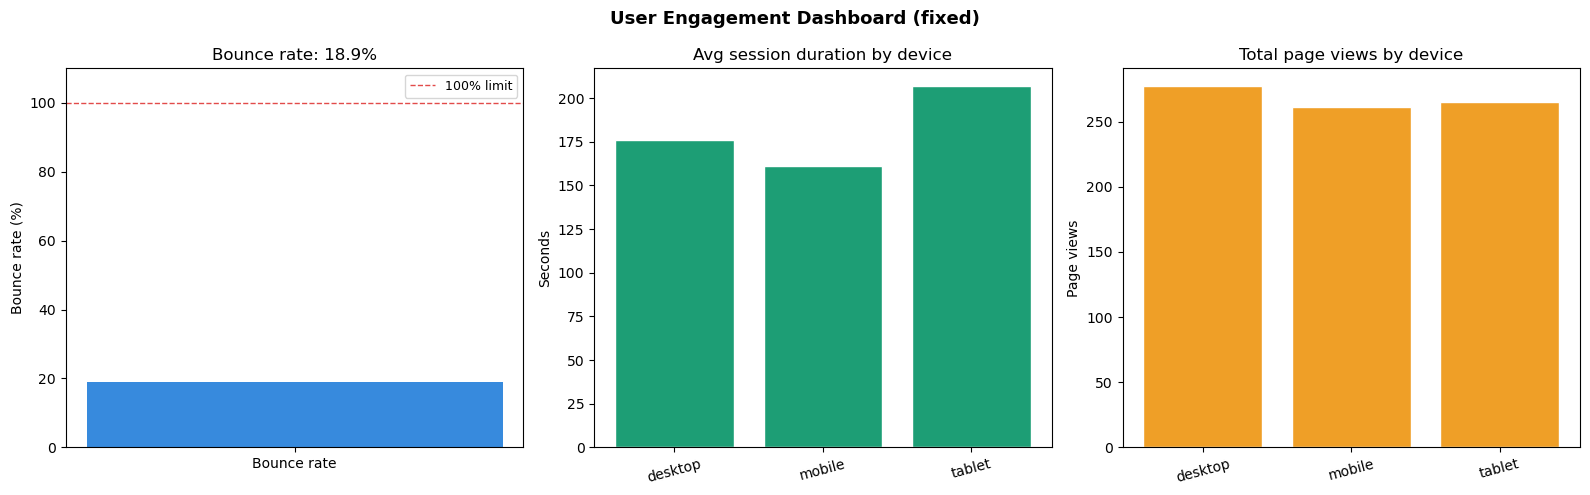

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# ── Synthetic demo data ───────────────────────────────────────────────────────
np.random.seed(7)
n_sessions = 200
session_ids    = [f'S{i:04d}' for i in range(n_sessions)]
device_types   = np.random.choice(['mobile', 'desktop', 'tablet'], n_sessions)

rows = []
for sid, dev in zip(session_ids, device_types):
    n_pages = np.random.randint(1, 8)
    for page in range(n_pages):
        rows.append({
            'session_id':  sid,
            'device_type': dev,
            'page_views':  1,
            'duration':    max(0, np.random.normal(45, 20)),   # seconds per page
        })
# Inject bad rows to test validation
rows.append({'session_id': None,  'device_type': 'mobile',
             'page_views': 1,     'duration': -30})
rows.append({'session_id': 'S999','device_type': 'desktop',
             'page_views': 1,     'duration': np.nan})

logs_df = pd.DataFrame(rows)


# ── Original broken function (preserved for comparison) ───────────────────────
def analyze_user_engagement_broken(logs_df):
    """
    ORIGINAL — contains three bugs (see comments).
    """
    metrics = {
        # BUG 1: .apply(lambda x: x == 1) returns a Series of booleans per group,
        # .mean() on a boolean Series gives the fraction of ROWS where page_views==1,
        # not the fraction of SESSIONS with only one page-view.
        # When a session has multiple rows each with page_views=1, every row is True →
        # mean = 1.0 → reported bounce rate = 100 % even for multi-page sessions.
        'bounce_rate': logs_df.groupby('session_id')['page_views'].apply(
            lambda x: x == 1).mean(),

        # BUG 2: .sum() returns a Series indexed by session_id, not a scalar.
        # Calling .mean() on a Series with potentially negative values (negative
        # duration rows) propagates nonsense into the average.
        'avg_session_time': logs_df.groupby('session_id')['duration'].sum(),

        # BUG 3: .mean() per session of a column that is always 1 (one row = one
        # page view) just gives 1.0 for every session. Pages per session should
        # be the COUNT of rows per session, not the mean of the page_views column.
        'pages_per_session': logs_df.groupby('session_id')['page_views'].mean()
    }
    device_metrics = logs_df.groupby('device_type').agg({
        'session_id': 'count',
        'duration': 'mean',
        'page_views': 'sum'
    })
    return metrics, device_metrics


# ── Input validation ──────────────────────────────────────────────────────────
def validate_logs(df: pd.DataFrame) -> pd.DataFrame:
    """
    Cleans the raw event log DataFrame.

    - Drops rows with null session_id
    - Replaces negative or null duration with 0
    - Ensures page_views is a non-negative integer

    Parameters
    ----------
    df : pd.DataFrame

    Returns
    -------
    pd.DataFrame  — cleaned copy with a report printed to stdout
    """
    df = df.copy()
    n_before = len(df)

    null_sid = df['session_id'].isna()
    if null_sid.any():
        print(f"  Dropped {null_sid.sum()} rows with null session_id")
    df = df[~null_sid]

    neg_dur = df['duration'] < 0
    null_dur = df['duration'].isna()
    if (neg_dur | null_dur).any():
        print(f"  Fixed {(neg_dur | null_dur).sum()} negative/null duration values → 0")
    df['duration'] = df['duration'].fillna(0).clip(lower=0)

    df['page_views'] = pd.to_numeric(df['page_views'], errors='coerce').fillna(0)
    df['page_views'] = df['page_views'].clip(lower=0).astype(int)

    print(f"  Validation: {n_before} → {len(df)} rows ({n_before - len(df)} removed)")
    return df


# ── Corrected engagement function ────────────────────────────────────────────
def analyze_user_engagement_fixed(logs_df: pd.DataFrame) -> tuple:
    """
    Correctly calculates user engagement metrics.

    Metrics
    -------
    bounce_rate       : fraction of sessions with exactly 1 page view (0–1)
    avg_session_time  : mean total session duration in seconds across all sessions
    pages_per_session : mean number of page-view events per session

    Device metrics    : session count, mean total duration, total page views
                        grouped by device_type

    Parameters
    ----------
    logs_df : pd.DataFrame  — raw event log (validated internally)

    Returns
    -------
    (metrics dict, device_metrics DataFrame)
    """
    df = validate_logs(logs_df)

    # Aggregate to one row per session first — this is the key fix
    session_summary = df.groupby('session_id').agg(
        total_pages    = ('page_views',  'sum'),
        total_duration = ('duration',    'sum'),
        device_type    = ('device_type', 'first'),
    ).reset_index()

    # Fix 1: bounce = sessions where total page views == 1
    bounce_rate = (session_summary['total_pages'] == 1).mean()

    # Fix 2: avg session time is the mean of per-session totals (in seconds)
    avg_session_time_sec = session_summary['total_duration'].mean()
    avg_session_time_str = str(timedelta(seconds=int(avg_session_time_sec)))

    # Fix 3: pages per session = mean of total_pages (not mean of the raw column)
    pages_per_session = session_summary['total_pages'].mean()

    metrics = {
        'bounce_rate':        round(bounce_rate, 4),
        'avg_session_time_s': round(avg_session_time_sec, 2),
        'avg_session_time':   avg_session_time_str,
        'pages_per_session':  round(pages_per_session, 2),
        'total_sessions':     len(session_summary),
    }

    device_metrics = (
        session_summary
        .groupby('device_type')
        .agg(
            session_count      = ('session_id',     'count'),
            avg_duration_s     = ('total_duration', 'mean'),
            total_page_views   = ('total_pages',    'sum'),
        )
        .round(2)
    )

    return metrics, device_metrics


# ── Visualisation ─────────────────────────────────────────────────────────────
def visualize_engagement(metrics: dict, device_metrics: pd.DataFrame) -> None:
    """
    Plots three engagement charts:
      1. Bounce rate gauge (bar vs. 100 % reference)
      2. Average session duration by device type
      3. Total page views by device type

    Parameters
    ----------
    metrics       : dict returned by analyze_user_engagement_fixed
    device_metrics: DataFrame returned by analyze_user_engagement_fixed
    """
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle('User Engagement Dashboard (fixed)', fontsize=13, fontweight='bold')

    # 1 — Bounce rate
    ax1 = axes[0]
    br = metrics['bounce_rate'] * 100
    ax1.bar(['Bounce rate'], [br], color='#378ADD', width=0.4)
    ax1.axhline(100, color='#E24B4A', linestyle='--', linewidth=1, label='100% limit')
    ax1.set_ylim(0, 110)
    ax1.set_ylabel('Bounce rate (%)')
    ax1.set_title(f'Bounce rate: {br:.1f}%')
    ax1.legend(fontsize=9)

    # 2 — Avg session duration by device
    ax2 = axes[1]
    ax2.bar(device_metrics.index, device_metrics['avg_duration_s'],
            color='#1D9E75', edgecolor='white')
    ax2.set_title('Avg session duration by device')
    ax2.set_ylabel('Seconds')
    ax2.tick_params(axis='x', rotation=15)

    # 3 — Total page views by device
    ax3 = axes[2]
    ax3.bar(device_metrics.index, device_metrics['total_page_views'],
            color='#EF9F27', edgecolor='white')
    ax3.set_title('Total page views by device')
    ax3.set_ylabel('Page views')
    ax3.tick_params(axis='x', rotation=15)

    plt.tight_layout()
    plt.savefig('engagement_dashboard.png', dpi=150, bbox_inches='tight')
    plt.show()


# ── Side-by-side comparison ───────────────────────────────────────────────────
print("=== BROKEN OUTPUT ===")
broken_metrics, _ = analyze_user_engagement_broken(logs_df)
print("Bounce rate (broken):", broken_metrics['bounce_rate'])
print("Avg session time is a Series, not scalar:\n",
      broken_metrics['avg_session_time'].head())

print("\n=== FIXED OUTPUT ===")
fixed_metrics, device_metrics = analyze_user_engagement_fixed(logs_df)
for k, v in fixed_metrics.items():
    print(f"  {k:25s}: {v}")

print("\nDevice metrics:")
print(device_metrics)

visualize_engagement(fixed_metrics, device_metrics)

### How did different prompts approach error identification?
- Column validation: Some prompts started by checking if all required columns existed in the DataFrame. Missing columns triggered a KeyError with a clear message.
- Division-by-zero detection: Bounce rate and turnover calculations were guarded against division by zero. Prompts identified potential errors by replacing zero denominators with safe defaults (like 1) or clamping ratios to logical bounds (≤ 1).
### What validation methods were suggested?
- Column existence checks: Confirming that all required columns (session_id, page_views, duration, timestamp, etc.) exist before running calculations.
- Null value handling : Dropping or filling rows with NaN in critical fields. For example, dropping rows with null session_id or timestamp to prevent broken session calculations.
- Negative value filtering : Removing rows where duration < 0 or page_views < 1, since these violate business assumptions (no negative time, at least one pageview per event)
### How was time handling improved?
- Session duration calculation : Early prompts mistakenly summed duration values per session, which could produce negatives or inflated totals. Later prompts fixed this by using

session_time
=
max
⁡
(
timestamp
)
−
min
⁡
(
timestamp
)
ensuring session time reflects the actual elapsed period.
- Negative duration handling : Invalid rows with negative duration were dropped, and any residual negatives were clamped to 0. This prevented impossible values from skewing averages.
-   